<a href="https://colab.research.google.com/github/alaaaitwork08-art/-/blob/main/assignment_ai_B%2BC_(V1_0)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ai colab/weather_dirty.csv',sep=';' )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
df.head(10)

,Date,Temperature_day,Temperature_night,AirPressure_hPa,WindSpeed_km/h,Wind_direction,Precipitation_mm,Outlook,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,01.07.2024,25.0,17.0,1022.0,5.0,NE,0.0,cloudless,NaN,NaN,NaN
1,02.07.2024,31.0,NaN,-1018.0,14.0,E,NaN,cloudy,NaN,NaN,NaN
2,03.07.2024,NaN,19.0,1003.0,16.0,NW,5.0,storm,NaN,NaN,NaN
3,04.07.2024,30.0,NaN,1020.0,1.0,W,0.0,cloudless,NaN,NaN,NaN
4,05.07.2024,33.0,20.0,1005.0,18.0,SW,NaN,storm,NaN,NaN,NaN
5,06.07.2024,29.0,17.0,1015.0,12.0,NE,0.0,cloudy,NaN,NaN,NaN
6,07.07.2024,NaN,16.0,NaN,12.0,NaN,0.0,cloudless,NaN,NaN,NaN
7,08.07.2024,31.0,NaN,1008.0,16.0,S,4.0,storm,NaN,NaN,NaN
8,09.07.2024,29.0,17.0,1016.0,12.0,W,0.0,cloudy,NaN,NaN,NaN
9,10.07.2024,28.0,19.0,1004.0,15.0,NW,NaN,storm,NaN,NaN,NaN


In [52]:
df = df.drop(columns={'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'},errors='ignore')

In [53]:
df = df.drop_duplicates()

In [54]:
df.describe()

,Temperature_day,Temperature_night,AirPressure_hPa,WindSpeed_km/h,Precipitation_mm
count,351.000000,299.000000,341.000000,353.000000,315.000000
mean,14.905983,7.217391,1649.398827,14.742210,2.876190
std,10.913936,8.668169,7671.933073,5.282244,3.612686
min,-4.000000,-8.000000,-1019.000000,1.000000,0.000000
25%,4.000000,0.000000,1002.000000,12.000000,0.000000
50%,15.000000,7.000000,1008.000000,15.000000,2.000000
75%,25.500000,16.000000,1015.000000,18.000000,5.000000
max,33.000000,22.000000,100060.000000,28.000000,18.000000


In [55]:
outlook = {
    "cloudless": "cloudy",
    "clouded": "cloudy",
    "clouds": "cloudy",
    "raining": "rain",
    "rainy": "rain",
    "rainy day": "rain",
    "rain/snow": "snow"
}
df["Outlook"] = df["Outlook"].replace(outlook)

In [56]:
important_cols = ["Temperature_day","Temperature_night","AirPressure_hPa","WindSpeed_km/h","Precipitation_mm"]

In [57]:
for col in df.columns:
    if col not in important_cols:
        if df[col].isna().sum() > 50:
            df = df.drop(columns=col)

In [58]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.dropna(subset=["Date"])

In [59]:
df.loc[df["AirPressure_hPa"] < 0, "AirPressure_hPa"] = np.nan

In [60]:
for col in important_cols:
    df[col] = df[col].ffill()
df["Temperature_day"] = df["Temperature_day"].round().astype(int)
df["Temperature_night"] = df["Temperature_night"].round().astype(int)
df["AirPressure_hPa"] = df["AirPressure_hPa"].round().astype(int)
df["WindSpeed_km/h"] = df["WindSpeed_km/h"].round().astype(int)

In [61]:
df["Outlook"] = df["Outlook"].fillna(df["Outlook"].mode()[0])
df["Wind_direction"] = df["Wind_direction"].ffill()

In [62]:
df["Precipitation_mm"] = pd.to_numeric(df["Precipitation_mm"],errors="coerce")
df.loc[df["Precipitation_mm"] == 0,"Precipitation_mm"] = np.nan
df["Precipitation_mm"] = df["Precipitation_mm"].fillna( df["Precipitation_mm"].mean())
df["Precipitation_mm"] = df["Precipitation_mm"].round().astype(int)

In [63]:
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 377
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               366 non-null    datetime64[ns]
 1   Temperature_day    366 non-null    int64         
 2   Temperature_night  366 non-null    int64         
 3   AirPressure_hPa    366 non-null    int64         
 4   WindSpeed_km/h     366 non-null    int64         
 5   Wind_direction     366 non-null    object        
 6   Precipitation_mm   366 non-null    int64         
 7   Outlook            366 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 25.7+ KB


,Date,Temperature_day,Temperature_night,AirPressure_hPa,WindSpeed_km/h,Wind_direction,Precipitation_mm,Outlook
0,2024-07-01,25,17,1022,5,NE,5,cloudy
1,2024-07-02,31,17,1022,14,E,5,cloudy
2,2024-07-03,31,19,1003,16,NW,5,storm
3,2024-07-04,30,19,1020,1,W,5,cloudy
4,2024-07-05,33,20,1005,18,SW,5,storm
5,2024-07-06,29,17,1015,12,NE,5,cloudy
6,2024-07-07,29,16,1015,12,NE,5,cloudy
7,2024-07-08,31,16,1008,16,S,4,storm
8,2024-07-09,29,17,1016,12,W,5,cloudy
9,2024-07-10,28,19,1004,15,NW,5,storm


In [64]:
# حفظ البيانات بعد التنظيف
df.to_csv("clean_weather_data.csv", index=False, encoding="utf-8-sig")

print("تم حفظ الملف")

تم حفظ الملف


#LinearRegression

Features used: ['Temperature_night', 'AirPressure_hPa', 'WindSpeed_km/h', 'Precipitation_mm']
Train size: 255
Val size  : 37
Test size : 74
MSE: 8.0573
RMSE: 2.8385
R2: 0.9314
Approx Accuracy: 93.14%


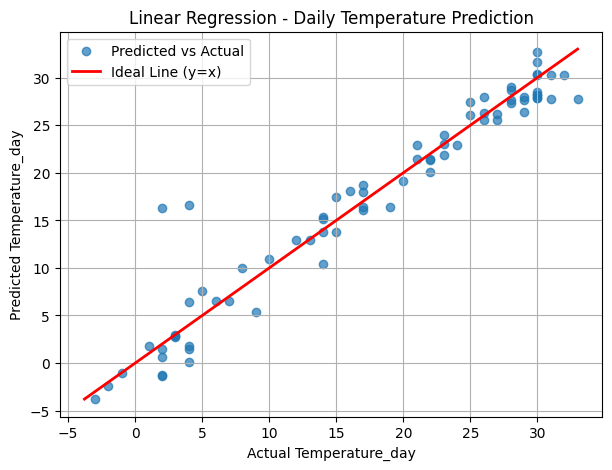

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd

cols = ["Temperature_day", "Temperature_night", "AirPressure_hPa", "WindSpeed_km/h", "Precipitation_mm"]
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

target_col = "Temperature_day"

feature_candidates = ["Temperature_night", "AirPressure_hPa", "WindSpeed_km/h", "Precipitation_mm"]
feature_cols = [c for c in feature_candidates if c in df.columns]

df2 = df.dropna(subset=feature_cols + [target_col]).copy()

X = df2[feature_cols]
y = df2[target_col]

print("Features used:", feature_cols)

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125, random_state=42
)

print("Train size:", len(X_train))
print("Val size  :", len(X_val))
print("Test size :", len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR2: {r2:.4f}\nApprox Accuracy: {r2*100:.2f}%")

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7, label="Predicted vs Actual")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, label="Ideal Line (y=x)")

plt.xlabel("Actual Temperature_day")
plt.ylabel("Predicted Temperature_day")
plt.title("Linear Regression - Daily Temperature Prediction")
plt.legend()
plt.grid(True)
plt.show()

#ARIMA


MAE  = 7.795
RMSE = 8.840
R2   = -1.2107
Approximate Accuracy = -121.07%


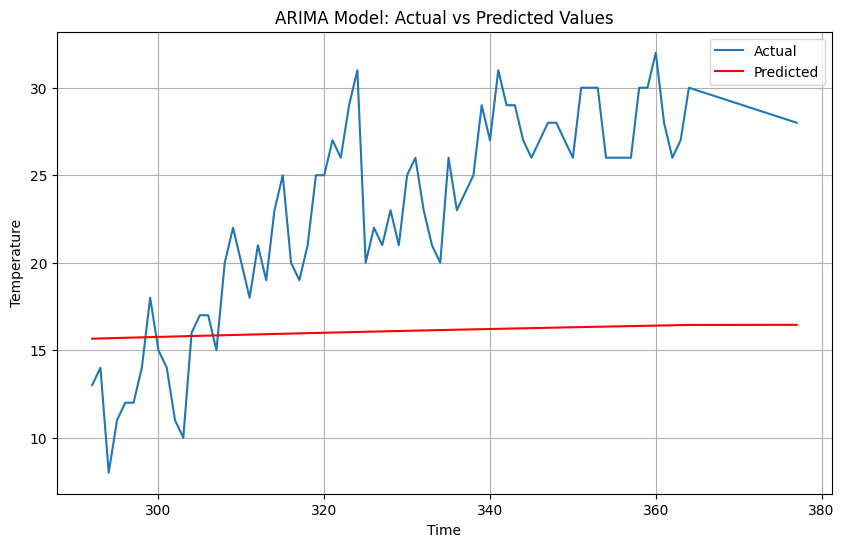

Next step prediction: 15.659241880663116


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

series = df["Temperature_day"].ffill()

split = int(len(series) * 0.8)
train, test = series.iloc[:split], series.iloc[split:]

model = ARIMA(train, order=(1, 0, 1)).fit()

pred = model.forecast(steps=len(test))

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
r2 = r2_score(test, pred)

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R2   = {r2:.4f}")

approx_accuracy = r2 * 100
print(f"Approximate Accuracy = {approx_accuracy:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(test, label="Actual")
plt.plot(test.index, pred, color="red", label="Predicted")
plt.title("ARIMA Model: Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

print("Next step prediction:", model.forecast(steps=1).iloc[0])

# KNN

KNN (k=5)  MSE=14.0368  MAE=2.5056  R2=0.8804


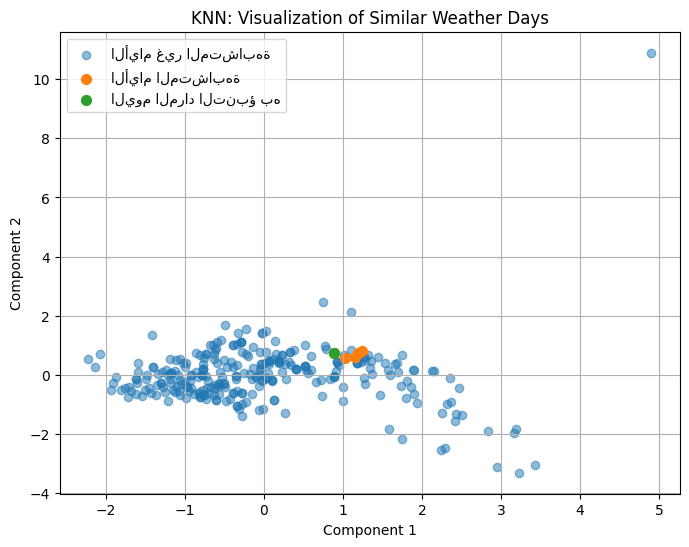


اليوم المراد التنبؤ به (Features): {'Temperature_night': -6, 'AirPressure_hPa': 1001, 'WindSpeed_km/h': 16, 'Precipitation_mm': 5}

أقرب 5 أيام مشابهة من التدريب:
1) distance=0.000 | {'Temperature_night': -6, 'AirPressure_hPa': 1000, 'WindSpeed_km/h': 16, 'Precipitation_mm': 5} | Temperature_day=1.00
2) distance=0.387 | {'Temperature_night': -7, 'AirPressure_hPa': 1004, 'WindSpeed_km/h': 18, 'Precipitation_mm': 5} | Temperature_day=-3.00
3) distance=0.424 | {'Temperature_night': -7, 'AirPressure_hPa': 998, 'WindSpeed_km/h': 16, 'Precipitation_mm': 6} | Temperature_day=-1.00
4) distance=0.437 | {'Temperature_night': -4, 'AirPressure_hPa': 1005, 'WindSpeed_km/h': 18, 'Precipitation_mm': 5} | Temperature_day=3.00
5) distance=0.437 | {'Temperature_night': -8, 'AirPressure_hPa': 997, 'WindSpeed_km/h': 18, 'Precipitation_mm': 5} | Temperature_day=-4.00

تنبؤ KNN لهذا اليوم = 1.0


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

feat = ["Temperature_night", "AirPressure_hPa", "WindSpeed_km/h", "Precipitation_mm"]
Xy = df[feat + ["Temperature_day"]].dropna()
X, y = Xy[feat], Xy["Temperature_day"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k = 5
model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k, weights="distance"))
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"KNN (k={k})  MSE={mean_squared_error(y_test,y_pred):.4f}  MAE={mean_absolute_error(y_test,y_pred):.4f}  R2={r2_score(y_test,y_pred):.4f}")

scaler = model.named_steps["standardscaler"]
knn    = model.named_steps["kneighborsregressor"]

Xt = scaler.transform(X_train)
xq = scaler.transform(X_test.iloc[[0]])

dist, idx = knn.kneighbors(xq, n_neighbors=k)

pca = PCA(n_components=2)
T2 = pca.fit_transform(Xt)
q2 = pca.transform(xq)

neighbors = T2[idx[0]]
others = np.delete(T2, idx[0], axis=0)

plt.figure(figsize=(8,6))
plt.scatter(others[:,0], others[:,1], alpha=0.5, label="الأيام غير المتشابهة")
plt.scatter(neighbors[:,0], neighbors[:,1], s=50, label="الأيام المتشابهة")
plt.scatter(q2[:,0], q2[:,1], s=50, label="اليوم المراد التنبؤ به")
plt.title("KNN: Visualization of Similar Weather Days")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.legend(); plt.grid(True); plt.show()

print("\nاليوم المراد التنبؤ به (Features):", X_test.iloc[0].to_dict())
print(f"\nأقرب {k} أيام مشابهة من التدريب:")
for r, (i, d) in enumerate(zip(idx[0], dist[0]), 1):
    print(f"{r}) distance={d:.3f} | {X_train.iloc[i].to_dict()} | Temperature_day={y_train.iloc[i]:.2f}")

print("\nتنبؤ KNN لهذا اليوم =", round(y_pred[0], 2))